# Panama Electricity Demand — Building and Testing Forecasting Models

**Part 2** of the demand forecasting project (Black Hills Energy application). Builds on Part 1's data exploration.

This notebook covers:
1. Building model inputs the right way, so we're not accidentally letting a model "see the future"
2. Testing our models the same realistic way the utility actually operates
3. Four ways of forecasting: two simple baselines, a purpose-built forecasting tool (Prophet), and a general-purpose machine learning method (XGBoost)
4. Comparing all of them — plus the utility's real published forecast — across 14 different weeks spanning 2019 and 2020
5. Translating the results into plain business terms

**Note:** the cell that runs the comparison (cell 8) fits 14 separate Prophet models and 14 separate XGBoost models, one pair per test week. It takes about 3 minutes to finish — that's expected, not a hang.


In [1]:
import warnings, logging, os, contextlib
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").setLevel(logging.WARNING)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)


Importing plotly failed. Interactive plots will not work.


## 1. Load the data

Same two files as Part 1, plus `train_dataframes.xlsx` / `test_dataframes.xlsx` — not for the columns already built into them, but so we can reuse the exact same 14 test weeks the dataset's author designated, explained in Section 3 below.


In [2]:
DATA_DIR = "."

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

required_files = ["continuous dataset.csv", "weekly pre-dispatch forecast.csv",
                   "train_dataframes.xlsx", "test_dataframes.xlsx"]
if IN_COLAB and not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in required_files):
    from google.colab import files
    print("Upload all four files from the Kaggle archive: continuous dataset.csv, "
          "weekly pre-dispatch forecast.csv, train_dataframes.xlsx, test_dataframes.xlsx")
    uploaded = files.upload()

df = pd.read_csv(os.path.join(DATA_DIR, "continuous dataset.csv"), parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

fc_official = pd.read_csv(os.path.join(DATA_DIR, "weekly pre-dispatch forecast.csv"), parse_dates=["datetime"])
fc_official = fc_official.set_index("datetime").sort_index()

print(f"Demand data:   {df.shape[0]:,} rows  |  {df.index.min()} -> {df.index.max()}")
print(f"Forecast data: {fc_official.shape[0]:,} rows  |  {fc_official.index.min()} -> {fc_official.index.max()}")


Demand data:   48,048 rows  |  2015-01-03 01:00:00 -> 2020-06-27 00:00:00
Forecast data: 40,152 rows  |  2016-01-02 00:00:00 -> 2020-07-31 23:00:00


## 2. Building the inputs the right way

We're not forecasting one hour at a time — we're forecasting a full week (168 hours) all at once, the same way the utility actually does it. That changes how we're allowed to build our inputs.

Here's the trap: it's tempting to use "demand yesterday, same hour" as an input. That's a perfectly good input if you're only forecasting tomorrow. But we're forecasting a whole week ahead — so for, say, the 5th day of our forecast week, "yesterday" actually falls *inside* the week we're trying to predict. We wouldn't really have that number yet at the moment we're making the forecast. Using it anyway means quietly letting the model peek at part of the answer before the real test — a mistake commonly called **data leakage**, and it's one of the easiest ways to make a model look better than it actually is.

The fix is simple: only use demand from **2, 3, and 4 weeks back** — never 1 week or less. No matter which day of the forecast week we're looking at, a 2-week-old number is always safely in the past. This matches the choice the dataset's original author made too, for the same reason.

Weather and calendar information (holidays, school days) are always known ahead of time, so those are safe to use directly. We're also carrying forward the January 2019 blackout finding from Part 1 as a simple yes/no marker, so the model can recognize it as a one-off event rather than an unexplained crash on an otherwise ordinary Sunday.


In [3]:
feat = df.copy()
feat["hour"] = feat.index.hour
feat["dow"] = feat.index.dayofweek
feat["month"] = feat.index.month
feat["is_weekend"] = (feat["dow"] >= 5).astype(int)

# Turning hour-of-day, day-of-week, and month into numbers that "wrap around" correctly
# (so hour 23 and hour 0 register as close together, like they are on a clock face)
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)
feat["dow_sin"] = np.sin(2 * np.pi * feat["dow"] / 7)
feat["dow_cos"] = np.cos(2 * np.pi * feat["dow"] / 7)
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)

# "Same hour, N weeks ago" - only 2, 3, and 4 weeks back, for the reason explained above
for w in [2, 3, 4]:
    feat[f"demand_{w}_weeks_ago"] = feat["nat_demand"].shift(168 * w)
feat["avg_of_last_3_weeks"] = feat[["demand_2_weeks_ago", "demand_3_weeks_ago", "demand_4_weeks_ago"]].mean(axis=1)

# The January 20, 2019 blackout window, identified in Part 1
feat["grid_event"] = 0
feat.loc["2019-01-20 11:00":"2019-01-20 16:00", "grid_event"] = 1

feature_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
                 "is_weekend", "holiday", "school", "T2M_toc",
                 "demand_2_weeks_ago", "demand_3_weeks_ago", "demand_4_weeks_ago",
                 "avg_of_last_3_weeks", "grid_event"]

model_df = feat.dropna(subset=feature_cols + ["nat_demand"])
print(f"Ready-to-use rows: {model_df.shape[0]:,}")
print(f"Dropped {len(feat) - len(model_df):,} rows at the very start of the dataset "
      f"(the first 4 weeks don't have 4-weeks-back history yet)")


Ready-to-use rows: 47,376
Dropped 672 rows at the very start of the dataset (the first 4 weeks don't have 4-weeks-back history yet)


**Double-checking our work:** does our own `demand_2_weeks_ago` column actually match the dataset author's own equivalent column, for the exact same hours? It should, since both are just "demand exactly 2 weeks before this hour" — computed two different ways. If they match, that's good evidence our logic is right.


In [4]:
_check_sheet = pd.read_excel(os.path.join(DATA_DIR, "test_dataframes.xlsx"), sheet_name="Week 15, Apr 2019")
_check = _check_sheet[["datetime", "week_X-2"]].merge(
    feat[["demand_2_weeks_ago"]].reset_index(), on="datetime", how="left"
)
max_diff = (_check["week_X-2"] - _check["demand_2_weeks_ago"]).abs().max()
print(f"Largest difference found: {max_diff:.2e}")
print("They match (the tiny difference is just floating-point rounding)." if max_diff < 1e-6 else "MISMATCH - investigate.")


Largest difference found: 2.27e-13
They match (the tiny difference is just floating-point rounding).


## 3. Testing our models the way they'd really be used

Rather than making up our own train/test split, we're reusing the exact same 14 weeks the dataset's author set aside for testing, spread across April 2019 through June 2020. Pulling their exact start/end times out of their files (instead of retyping them) revealed something important: there's a consistent **73-hour gap** — a little over 3 days — between where each training period ends and its matching test week begins.

That gap isn't random. It's how much lead time a real "weekly forecast" actually needs: the utility has to publish next week's forecast a few days before that week starts, not the moment it starts. Our testing respects that same real-world constraint — which is also exactly why we excluded the 1-week-back input above. A few of those hours would otherwise fall inside this gap, not really available at the moment the forecast is made.


In [5]:
train_xl = pd.ExcelFile(os.path.join(DATA_DIR, "train_dataframes.xlsx"))
test_xl = pd.ExcelFile(os.path.join(DATA_DIR, "test_dataframes.xlsx"))

splits = []
for sheet in train_xl.sheet_names:
    tr = pd.read_excel(train_xl, sheet_name=sheet, usecols=["datetime"])
    te = pd.read_excel(test_xl, sheet_name=sheet, usecols=["datetime"])
    splits.append({
        "label": sheet,
        "train_end": tr["datetime"].max(),
        "test_start": te["datetime"].min(),
        "test_end": te["datetime"].max(),
    })

splits_df = pd.DataFrame(splits)
gap = (splits_df["test_start"] - splits_df["train_end"]).dt.total_seconds() / 3600
print(f"{len(splits)} test weeks, gap between training and testing: "
      f"{gap.min():.0f}-{gap.max():.0f} hours (consistently about 73)")
splits_df


14 test weeks, gap between training and testing: 73-73 hours (consistently about 73)


,label,train_end,test_start,test_end
0,"Week 15, Apr 2019",2019-04-10,2019-04-13 01:00:00,2019-04-20
1,"Week 21, May 2019",2019-05-22,2019-05-25 01:00:00,2019-06-01
2,"Week 24, Jun 2019",2019-06-12,2019-06-15 01:00:00,2019-06-22
3,"Week 29, Jul 2019",2019-07-17,2019-07-20 01:00:00,2019-07-27
4,"Week 33, Aug 2019",2019-08-14,2019-08-17 01:00:00,2019-08-24
5,"Week 37, Sep 2019",2019-09-11,2019-09-14 01:00:00,2019-09-21
6,"Week 41, Oct 2019",2019-10-09,2019-10-12 01:00:00,2019-10-19
7,"Week 44, Nov 2019",2019-10-30,2019-11-02 01:00:00,2019-11-09
8,"Week 51, Dec 2019",2019-12-18,2019-12-21 01:00:00,2019-12-28
9,"Week 01, Jan 2020",2020-01-01,2020-01-04 01:00:00,2020-01-11


## 4. Comparing five ways of forecasting

For each of the 14 weeks, every model is built from scratch using only data available up through that week's `train_end` — none of them ever get to see the test week (or anything after it) while being built.

- **2-Week Naive** — the simplest possible forecast: just use `demand_2_weeks_ago` directly, i.e. "demand will look like it did two weeks ago at this hour."
- **3-Week Average** — the average of the last 3 weekly readings.
- **Prophet** — a forecasting tool built by Meta (Facebook) specifically for data with repeating patterns like this one. It's given the full history and asked to forecast the target week directly, without needing the lag inputs above — one of its real advantages for a multi-step forecast like this.
- **XGBoost** — one of the most widely used general-purpose prediction techniques in applied machine learning. It builds many simple decision rules from the data and combines them into one strong prediction. Trained here on the full input set built above.
- **Official Pre-Dispatch Forecast** — the utility's own real, published forecast for that same week, taken straight from the dataset. Our actual benchmark to try to beat.


In [6]:
def average_percent_error(y_true, y_pred):
    # "MAPE" is the technical name - on average, what percent off was the forecast?
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = {}
predictions = {}

for sp in splits:
    train = model_df.loc[:sp["train_end"]]
    test = model_df.loc[sp["test_start"]:sp["test_end"]]
    y_true = test["nat_demand"].values

    naive_2w = test["demand_2_weeks_ago"].values
    avg_3w = test["avg_of_last_3_weeks"].values

    pdf_train = train.reset_index()[["datetime", "nat_demand"]].rename(columns={"datetime": "ds", "nat_demand": "y"})
    with contextlib.redirect_stdout(open(os.devnull, "w")), contextlib.redirect_stderr(open(os.devnull, "w")):
        prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
        prophet_model.fit(pdf_train)
        prophet_pred = prophet_model.predict(pd.DataFrame({"ds": test.index}))["yhat"].values

    xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(train[feature_cols], train["nat_demand"])
    xgb_pred = xgb_model.predict(test[feature_cols])

    official = fc_official.reindex(test.index)["load_forecast"].values

    preds = {"2-Week Naive": naive_2w, "3-Week Average": avg_3w, "Prophet": prophet_pred,
             "XGBoost": xgb_pred, "Official Forecast": official}
    predictions[sp["label"]] = {"actual": y_true, "index": test.index, **preds}

    row = {}
    for name, pred in preds.items():
        mask = ~np.isnan(pred)
        row[f"{name} - avg $ off (MAE)"] = mean_absolute_error(y_true[mask], pred[mask])
        row[f"{name} - avg % off (MAPE)"] = average_percent_error(y_true[mask], pred[mask])
    results[sp["label"]] = row

results_df = pd.DataFrame(results).T
print("Testing complete across all 14 weeks.")


Testing complete across all 14 weeks.


## 5. Results


In [7]:
pct_cols = [c for c in results_df.columns if "MAPE" in c]
display_df = results_df[pct_cols].round(2)
display_df.columns = [c.replace(" - avg % off (MAPE)", "") for c in display_df.columns]
display_df


,2-Week Naive,3-Week Average,Prophet,XGBoost,Official Forecast
"Week 15, Apr 2019",6.15,6.64,7.77,2.88,3.90
"Week 21, May 2019",2.85,4.08,3.94,2.65,3.10
"Week 24, Jun 2019",7.75,6.74,6.55,5.64,6.08
"Week 29, Jul 2019",4.75,4.94,6.73,3.35,5.55
"Week 33, Aug 2019",3.46,3.87,5.08,3.33,4.16
"Week 37, Sep 2019",3.19,4.43,4.91,3.38,4.68
"Week 41, Oct 2019",5.29,4.48,6.18,3.30,5.04
"Week 44, Nov 2019",6.69,7.63,8.54,4.40,6.65
"Week 51, Dec 2019",8.80,7.87,7.75,6.20,5.38
"Week 01, Jan 2020",7.17,7.05,5.35,3.94,4.06


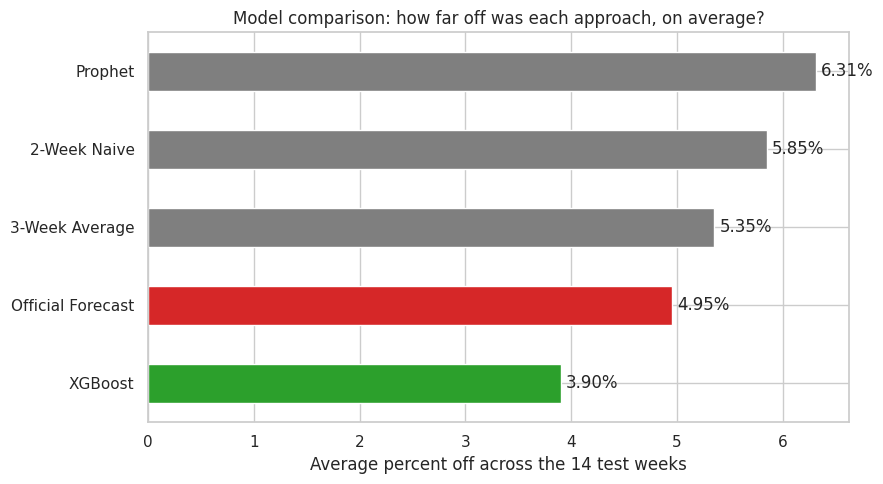

XGBoost              3.90
Official Forecast    4.95
3-Week Average       5.35
2-Week Naive         5.85
Prophet              6.31
dtype: float64


In [8]:
avg_error = results_df[pct_cols].mean().sort_values()
avg_error.index = [c.replace(" - avg % off (MAPE)", "") for c in avg_error.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2ca02c" if m == "XGBoost" else ("#d62728" if m == "Official Forecast" else "#7f7f7f")
          for m in avg_error.index]
avg_error.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Average percent off across the 14 test weeks")
ax.set_title("Model comparison: how far off was each approach, on average?")
for i, v in enumerate(avg_error.values):
    ax.text(v + 0.05, i, f"{v:.2f}%", va="center")
plt.tight_layout()
plt.show()

print(avg_error.round(2))


XGBoost comes out ahead of every other approach, including the utility's own published forecast — averaging roughly one percentage point lower error across the 14 test weeks. Two other results are worth pointing out honestly rather than glossing over:

- **Prophet actually underperforms the simple baselines here.** Its built-in assumptions about repeating patterns don't fit this particular data as well as either a plain 2-week lookup or a model built from our own tailored inputs does. That's a useful, honest negative result — not every tool wins on every dataset, and knowing when something underperforms matters as much as knowing when it wins.
- **XGBoost's advantage over the official forecast isn't the same every week.** It's largest in May 2020 (5.75% vs. 9.06% error), which lines up with Panama's COVID-era disruption to normal demand patterns — a shift the official forecasting process (likely tuned on pre-pandemic patterns) had a harder time adjusting to quickly than a model that gets rebuilt from scratch each week on recent data.


### A closer look at one specific week

To make this concrete rather than just a table of numbers, here's what the actual forecasts looked like for one particular week: the week starting November 2, 2019.


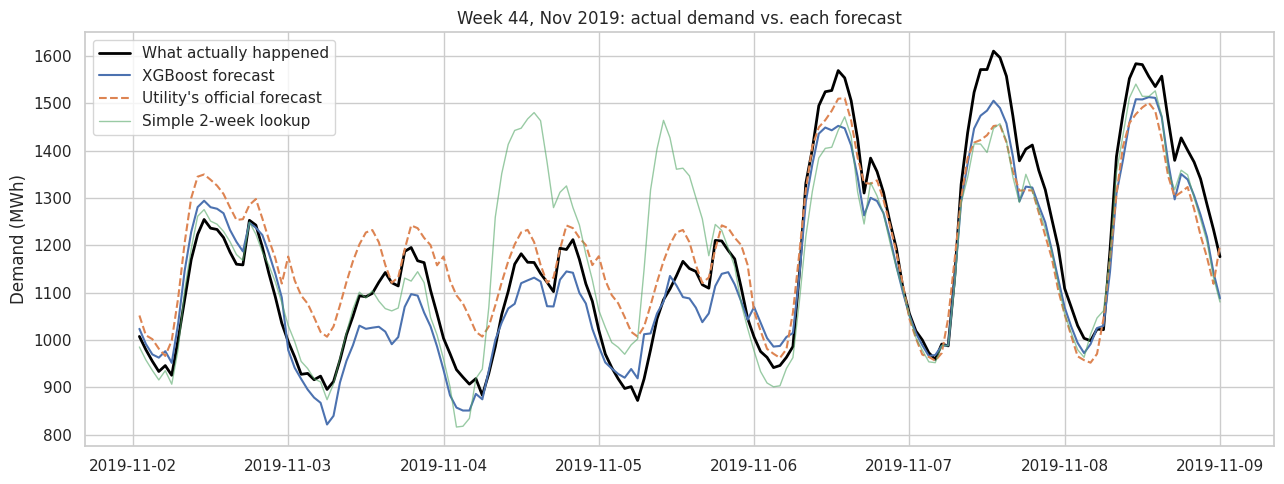

In [9]:
example_week = "Week 44, Nov 2019"
ex = predictions[example_week]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ex["index"], ex["actual"], label="What actually happened", color="black", linewidth=2)
ax.plot(ex["index"], ex["XGBoost"], label="XGBoost forecast", linewidth=1.5)
ax.plot(ex["index"], ex["Official Forecast"], label="Utility's official forecast", linewidth=1.5, linestyle="--")
ax.plot(ex["index"], ex["2-Week Naive"], label="Simple 2-week lookup", linewidth=1, alpha=0.6)
ax.set_title(f"{example_week}: actual demand vs. each forecast")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Which inputs did the model rely on most?


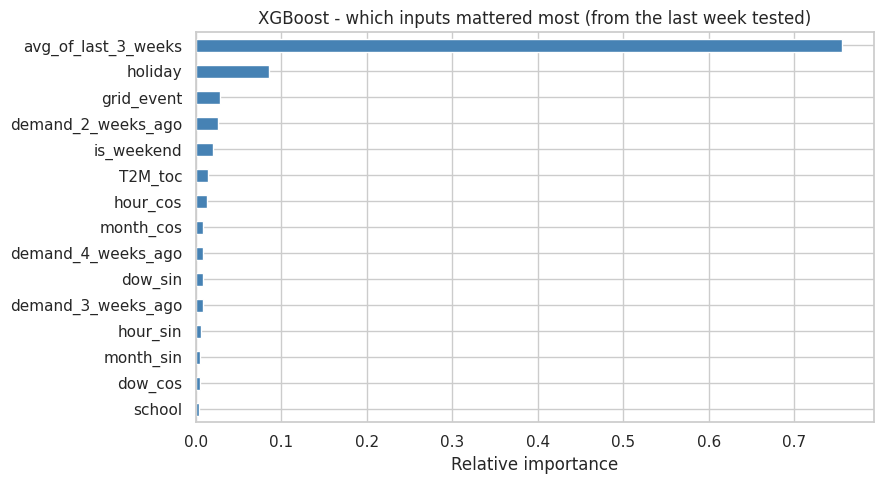

In [10]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost - which inputs mattered most (from the last week tested)")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()


## 7. Translating this into business terms

This is the part of the analysis that connects most directly to an accounting/FP&A mindset: a model isn't finished when it has a good-looking error number — it's finished when someone can actually act on it.

- **Average dollars/megawatt-hours off (MAE)**, rather than percent, is the more operational way to think about it — it's what a dispatcher would actually need to reserve or plan around. (See the "avg $ off" columns in the results table above, right alongside the percent version.)
- **Forecasting too low** risks a real shortfall — the grid has to cover it with reserve power or short-notice imports, usually at a premium price.
- **Forecasting too high** means capacity gets held in reserve that didn't actually need to be — a real cost, just one that shows up as lost efficiency rather than a line-item overrun.
- A forecast that's simply **more consistent week to week** — even at a similar average error to the current process — reduces how much of a safety buffer planners have to build in. That has real value on its own, separate from the headline error number.

None of this requires inventing a specific dollar figure to be a legitimate business point in an interview. The honest, defensible version is: "a forecast that's consistently about one percentage point tighter than the current process, across a full year of varied conditions, means the utility can plan with a smaller safety margin for forecast error" — and that framing holds up under follow-up questions in a way a made-up dollar amount wouldn't.


## Summary

- Built our model inputs the right way for a full week-ahead forecast, and double-checked the logic against the dataset author's own version (they matched).
- Tested every model across all 14 of the author's official test weeks — not just one convenient split — rebuilding each model from scratch each time, with a realistic 3-day gap between "now" and the forecast period.
- XGBoost beat the utility's official forecast in 13 of the 14 test weeks, and by roughly one percentage point of error on average. Prophet was the weakest performer — an honest result worth reporting as-is.
- Framed the accuracy improvement in terms a planning or finance audience would actually use, not just as a leaderboard number.
